<a href="https://colab.research.google.com/github/ShlokVaibhav/DSP/blob/main/Costas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Costas Loop implementation

The costas loop is implemented, carrier frequency is 32Hz, the local oscillator has an initial frequency of 35Hz, after frequency synchronization, there is a phase error of 16 degrees. The loop stability is unsatisfactory, it takes around a second to lock-in

### AI Usage: LLMs consulted for suggestions for python syntax only

In [117]:
import numpy as np
import matplotlib.pyplot as plt

def VCO(K, dt, phi_0, f):
    # VCO instead of NCO implemented for now, it starts with a frequency of 35 Hz instead of 32Hz
    phi = phi_0+2*np.pi*(30+K*f)*dt
    return (phi)

def Mixer(f1, f2):
    return f1*f2

def LPF_Costas(x, y0, dt, f_C):
    # Forward Euler based LPF after the envelope detector to remove noise, 3dB frequency  at f_C
    RC = 1/(f_C*2*np.pi)
    y = y0+(x-y0)/RC*dt
    return y

Fc = 32        # Carrier Frequency
Fs = 1024      # Sampling rate
dt = 1/Fs
Fsym = 0.25    # Symbol rate
t_stop = 8/Fsym   # Sim time
time = np.arange(0, t_stop, dt)   # time grid
Data = np.array([0, 1, 0, 0, 1, 0, 1, 1])      # Data to be transmitted
Phase = np.pi*np.repeat(Data, np.round(1/Fsym*Fs))  # BPSK Phase based on data, either 0 or pi
x = np.sin(2*np.pi*Fc*time+Phase)            # Carrier Wave

def Costas_Loop(x, time, PLL_EN=0):
    # Costas loop is implemented here
    #Initializing internal state of the costas loop, all these variables are local in scope to the Costas Function
    x_lo = np.zeros(x.shape)
    x_lo_sin = np.zeros(x.shape)
    
    x_VCO = np.zeros(x.shape)
    x_VCO_sin = np.zeros(x.shape)
    phi_VCO = np.zeros(x.shape)
    y = np.zeros(x.shape)
    y1 = np.zeros(x.shape)
    y2 = np.zeros(x.shape)
    ys = np.ones(x.shape)
    y1s = np.zeros(x.shape)
    y2s = np.zeros(x.shape)
    
    y[0] = 0.4
    y1[0] = 0.4
    y2[0] = 0.4
    ys[0] = 0.4
    y1s[0] = 0.4
    y1s[0] = 0.4
    
    PLL = PLL_EN
    if PLL==1: # We are implementing PLL, ie only one feedback path is implemented
        #the result is much greater phase error
        
        for ind in range(1, len(y)):
            #VCO output
            phi_VCO[ind] = VCO(10, dt, phi_VCO[ind-1], y[ind-1])
            x_VCO[ind] = np.cos(phi_VCO[ind])
            #Local oscillator output
            x_lo[ind] = x_VCO[ind]*x[ind]
            #Low pass filter and its internal state
            y1[ind] = LPF_Costas(x_lo[ind], y1[ind-1], dt, 6)
            y2[ind] = LPF_Costas(y1[ind], y2[ind-1], dt, 9)
            y[ind] = LPF_Costas(y2[ind], y[ind-1], dt, 12)
        plt.figure(figsize=(14, 5))
        plt.plot(time, np.acos(2*y)*180/np.pi)
        plt.title("Phase Error (Degrees)")
        plt.xlabel("time (s)")
        plt.show()   

    else: # We are implementing Costas Loop, now both feedback paths are implemented and phase error is less
        for ind in range(1, len(y)):
            # VCO outputs (Both I and Q)
            phi_VCO[ind] = VCO(30, dt, phi_VCO[ind-1], y[ind-1]*ys[ind-1])
            x_VCO[ind] = np.cos(phi_VCO[ind])
            x_VCO_sin[ind] = -np.sin(phi_VCO[ind])
            # Local Oscillator outputs
            x_lo[ind] = x_VCO[ind]*x[ind]
            x_lo_sin[ind] = x_VCO_sin[ind]*x[ind]

            # LPFs and their internal states
            y1[ind] = LPF(x_lo[ind], y1[ind-1], dt, 6)
            y2[ind] = LPF(y1[ind], y2[ind-1], dt, 9)
            y[ind] = LPF(y2[ind], y[ind-1], dt, 12)
            y1s[ind] = LPF(x_lo_sin[ind], y1s[ind-1], dt, 6)
            y2s[ind] = LPF(y1s[ind], y2s[ind-1], dt, 9)
            ys[ind] = LPF(y2s[ind], ys[ind-1], dt, 12)
        plt.figure(figsize=(14, 5))
        plt.plot(time, 4*180/np.pi*y*ys)
        plt.title("Phase Error (Degrees)")
        plt.xlabel("time (s)")
        plt.show()   
    
    
    x11 = -np.sin(2*np.pi*Fc*time-np.pi/180*120)
    
    plt.figure(figsize=(14, 5))
    plt.plot(time[0:500], x[0:500])
    plt.plot(time[0:500], -x_VCO[0:500])
    plt.title("Received Signal and Local Oscillator before lock-in (Notice Frequency drift)")
    plt.xlabel("Time (s)")
    plt.show()
    
    plt.figure(figsize=(14, 5))
    plt.plot(time[-500:-1], x[-500:-1])
    plt.plot(time[-500:-1], -x_VCO[-500:-1])
    plt.title("Received Signal and Local Oscillator after lock-in")
    plt.xlabel("Time (s)")
    plt.show()


# Costas loop with both I and Q feedback paths
Resulting phase error given as $\phi \approx VCO_{IN}/4$  (Here $16^\circ$)

Stability is marginal

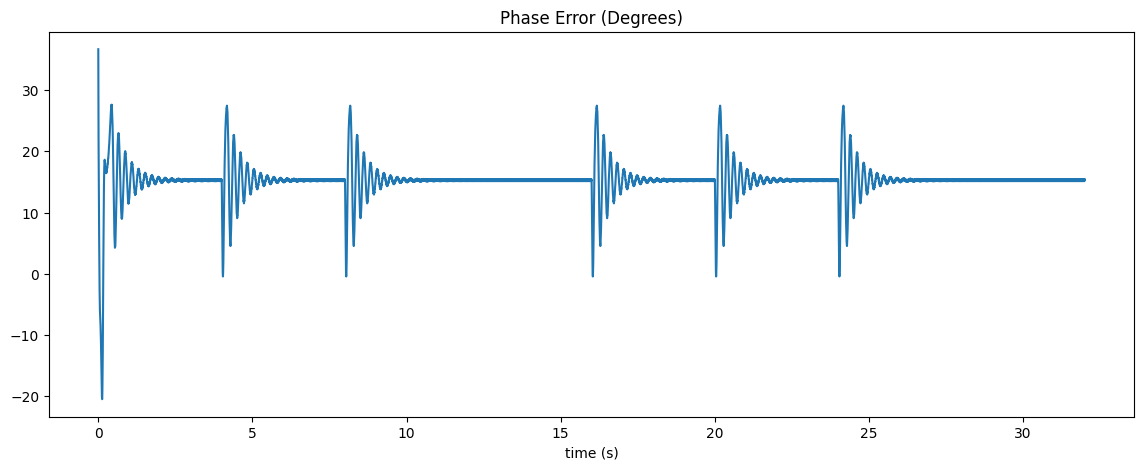

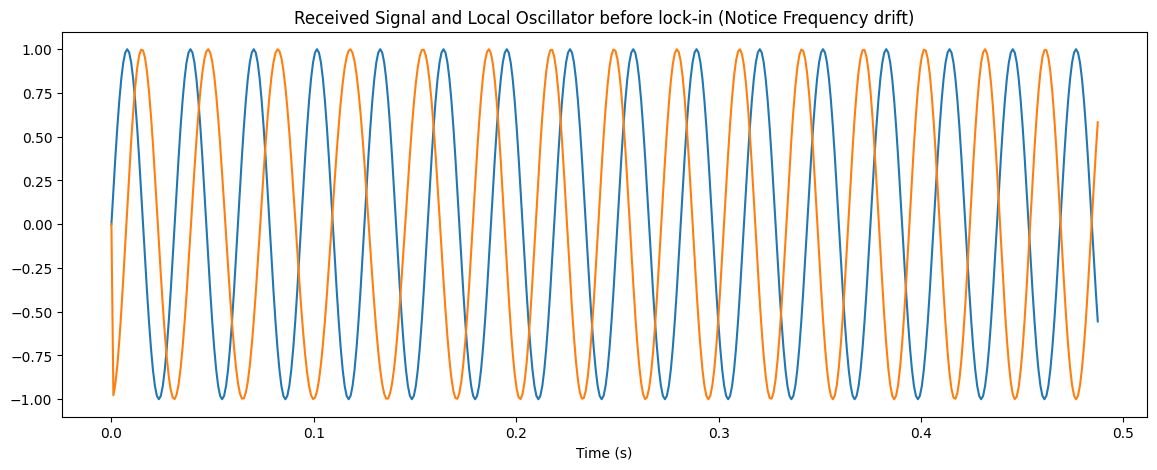

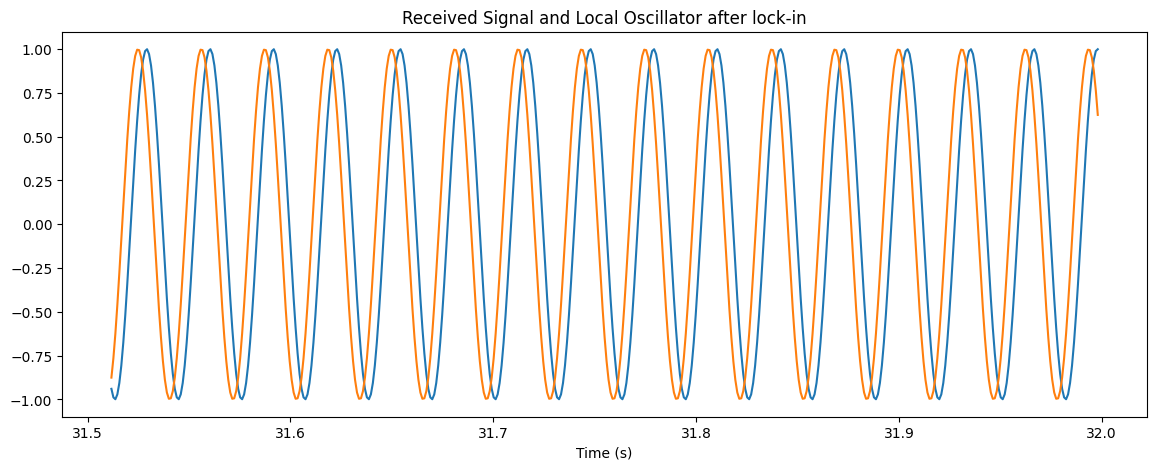

In [109]:
Costas_Loop(x, time)

# Costas loop with only I path
Result is much greater phase error than above, given as $\phi = \cos^{-1}(2*VCO_{IN})$ (Here $120^\circ$)

Stability is marginal

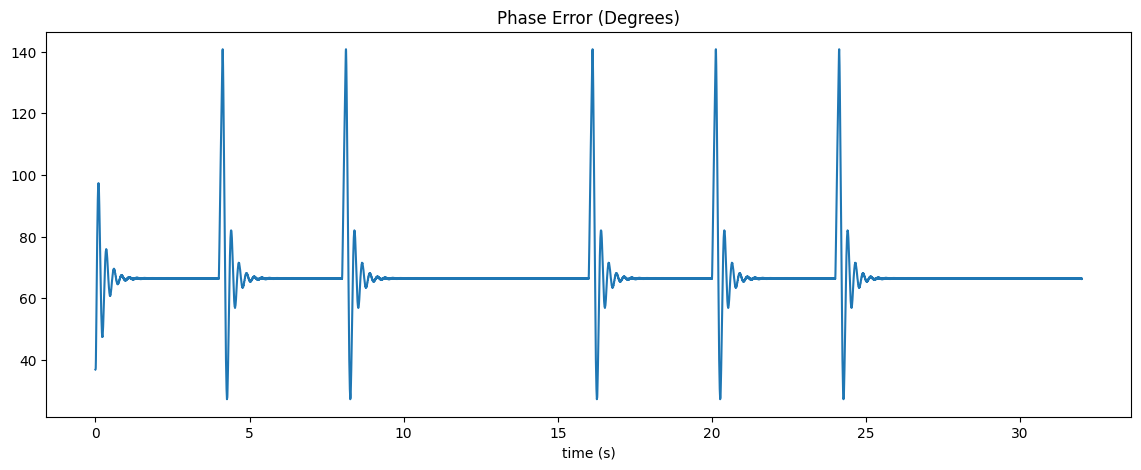

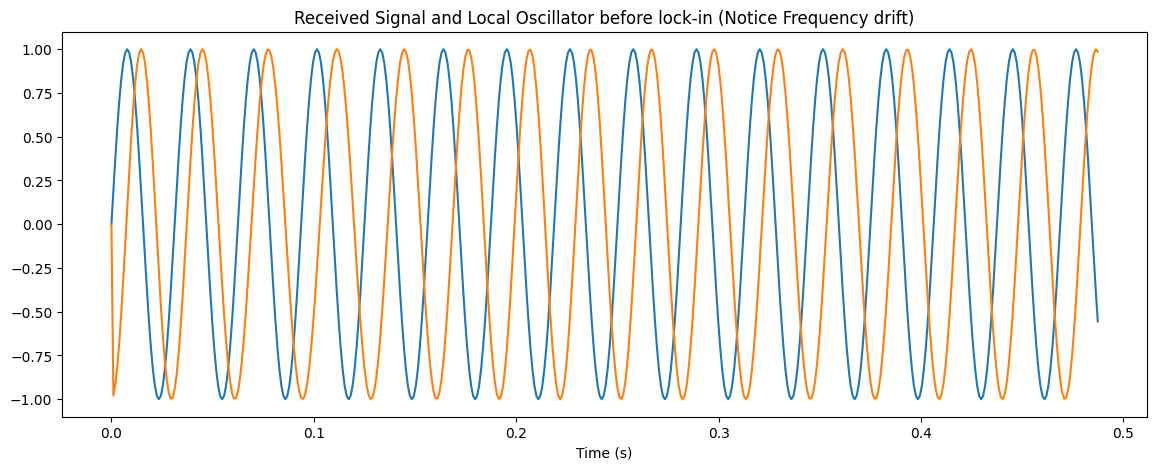

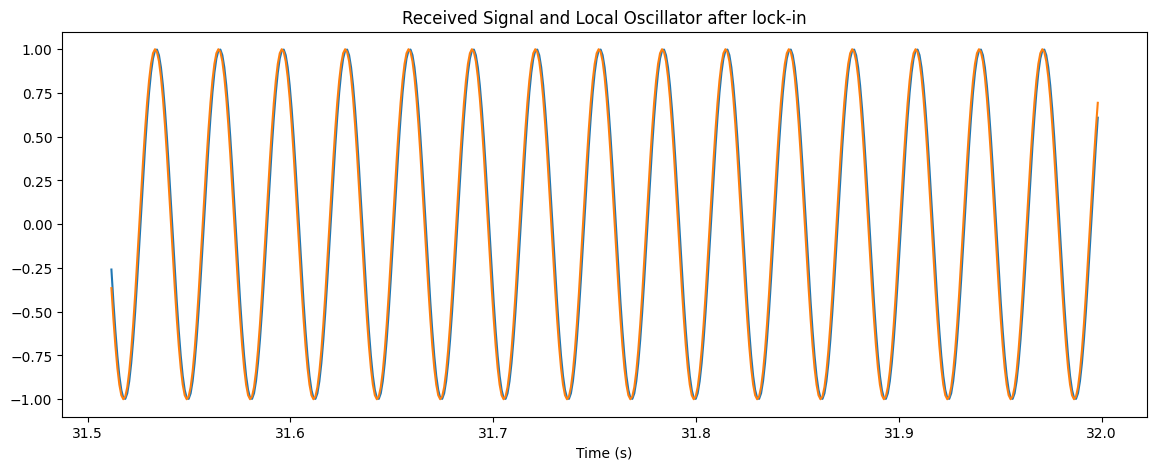

In [118]:
Costas_Loop(x, time, 1)